# Phase 2 — EDA + Survival Analysis

With the data validated in Phase 1, we now look for the *patterns* the model will
need to capture and the *groups* that matter most for the cost-aware decision
rule downstream.

---

### What we're looking for in this phase

This isn't generic EDA. We're looking for specific things that will shape the
model and the decision rule in later phases:

1. **Which groups of subscribers churn the most?** Those are the groups the
   Retention team should target first, no matter what the model later says. If
   the model's improvement over targeting these groups is small, the model isn't
   worth the effort.

2. **Does declining engagement really predict churn?** If churners' recent watch
   time doesn't differ from non-churners', the trend feature we built is useless
   and should be removed before training.

3. **Do month 2 and month 12 actually show as churn spikes?** The PM brief said
   they would. If they do, the model has to capture them. If they don't, we
   wasted effort.

4. **Does survival by plan tier and billing cycle match how real services look?**
   Annual billing should hold users ~3× longer than monthly. Premium tier should
   retain longer than Basic. If those orderings flip, something is wrong with the
   data.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_subscribers("../data/subscribers.csv")
print(f"Loaded {len(df):,} subscribers, {len(df.columns)} columns")


Loaded 50,000 subscribers, 28 columns


## A. Who's in the Dataset?

Quick scan of which groups are big and which are small. Helps us judge whether a
group's churn rate matters at the total-business level.

> **Why group size matters as much as group risk.** The decision rule will pick
> who to target based on both how risky they are AND how many of them there are.
> A 1% increase in churn across 35,000 monthly subscribers is a bigger total
> problem (and bigger opportunity) than a 5% increase across just 1,000 Premium
> subscribers. So we look at both the share of each group and its churn rate.


In [2]:
for col in ["plan_tier", "billing_cycle", "country", "payment_method",
            "engagement_cohort", "auto_renew", "multi_profile", "promo_active"]:
    if df[col].dtype == bool:
        share = df[col].mean()
        print(f"  {col:<22}  True share = {share:.1%}")
    else:
        top_shares = df[col].value_counts(normalize=True).round(3)
        print(f"  {col}:")
        for k, v in top_shares.items():
            print(f"      {k:<15} {v:.1%}")


  plan_tier:
      Standard        40.4%
      Basic           39.7%
      Premium         19.9%
  billing_cycle:
      monthly         69.0%
      annual          31.0%
  country:
      US              49.9%
      Other           17.0%
      UK              15.3%
      CA              9.9%
      AU              7.8%
  payment_method:
      credit_card     65.2%
      paypal          24.8%
      gift_card       10.0%
  engagement_cohort:
      regular         60.2%
      casual          24.8%
      heavy           15.0%
  auto_renew              True share = 85.3%
  multi_profile           True share = 43.0%
  promo_active            True share = 12.0%


## B. Churn Rate by Group

For each group (plan tier, billing cycle, payment method, etc.), what's the churn
rate? Compare each group to the overall average to see which stand out.

> **Why we flag groups at 1.5× the average.** If a group's churn rate is more
> than 50% above the overall average (so ≥ ~8.3%), the Retention team could just
> target that whole group — no model needed. This sets the bar the model has to
> beat. If our fancy model can't do better than "target everyone who fits this
> rule," we don't really need the model.


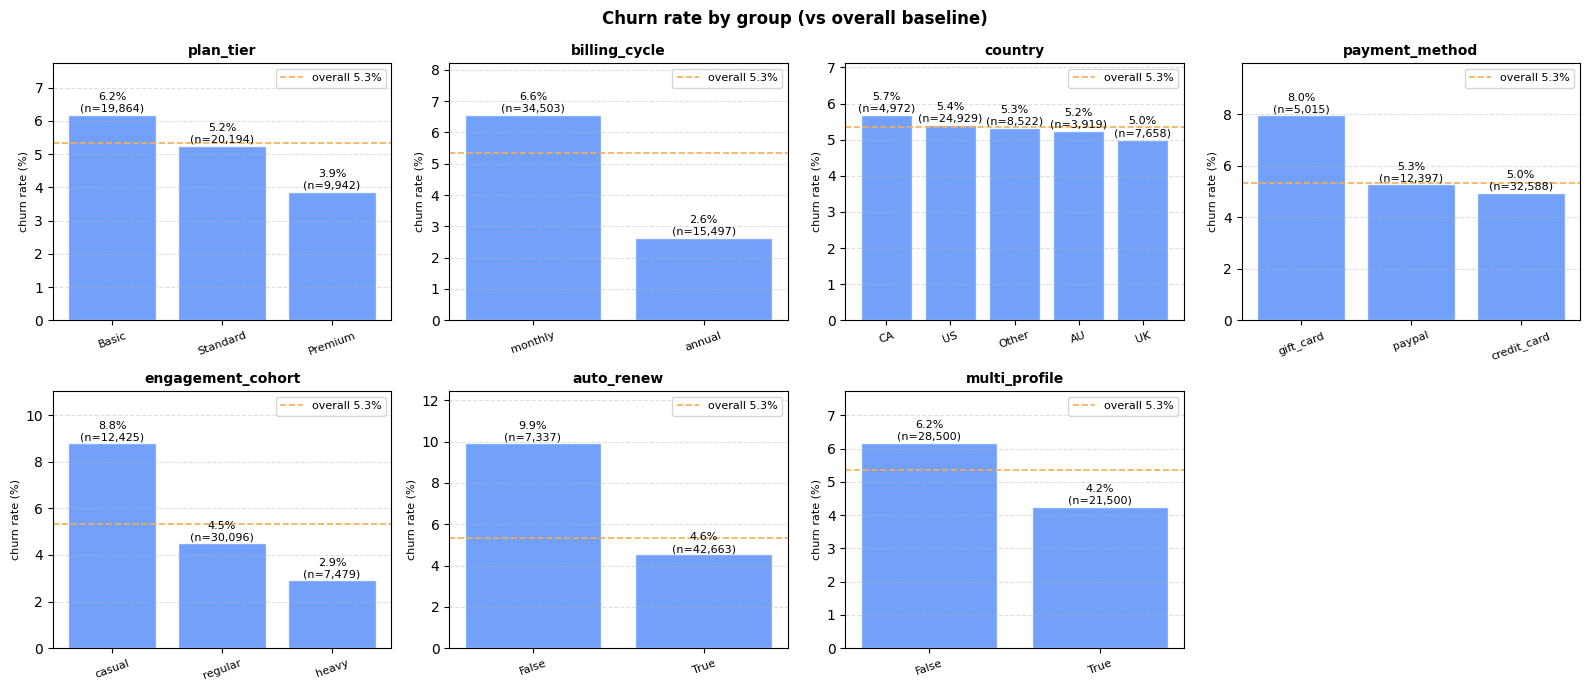


Overall churn rate: 5.34%
Groups with churn rate >= 1.5x baseline:
  engagement_cohort    = casual           rate = 8.82%
  auto_renew           = 0                rate = 9.95%


In [3]:
seg_cols = ["plan_tier", "billing_cycle", "country", "payment_method",
            "engagement_cohort", "auto_renew", "multi_profile"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
overall_rate = df["churned_next_30d"].mean()

for ax, col in zip(axes, seg_cols):
    seg = df.groupby(col)["churned_next_30d"].agg(["mean", "count"]).reset_index()
    seg = seg.sort_values("mean", ascending=False)
    bars = ax.bar(seg[col].astype(str), seg["mean"] * 100,
                  color="#5B8FF9", alpha=0.85, edgecolor="white")
    ax.axhline(overall_rate * 100, color="#F6AD55", linestyle="--",
               linewidth=1.2, label=f"overall {overall_rate:.1%}")
    for b, rate, n in zip(bars, seg["mean"], seg["count"]):
        ax.text(b.get_x() + b.get_width() / 2, rate * 100 + 0.1,
                f"{rate:.1%}\n(n={n:,})", ha="center", fontsize=8)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_ylabel("churn rate (%)", fontsize=8)
    ax.set_ylim(0, max(seg["mean"]) * 100 * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_visible(False)
plt.suptitle("Churn rate by group (vs overall baseline)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_churn_by_segment.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"\nOverall churn rate: {overall_rate:.2%}")
print("Groups with churn rate >= 1.5x baseline:")
for col in seg_cols:
    seg = df.groupby(col)["churned_next_30d"].mean()
    for seg_val, rate in seg.items():
        if rate >= 1.5 * overall_rate:
            print(f"  {col:<20} = {seg_val:<15}  rate = {rate:.2%}")


## C. Survival Curves — How Long Subscribers Stick Around

Survival curves answer: *of subscribers at a given tenure, what percent are still
around?* This gives a richer view than a single churn rate.

> **Why I write the survival math from scratch instead of installing a library.**
> The calculation is only about 10 lines of code — adding a whole library just
> for this would be overkill. In a real production setting I'd use the library
> for fancier things like confidence intervals, but the chart looks the same.
>
> **What I expect the charts to show.**
> - Annual subscribers should stick around about 3× longer than monthly ones —
>   they paid up front and committed to a year.
> - Premium users should hold on longer than Standard, who should hold on longer
>   than Basic. Premium users tend to be more invested from day one.
> - The overall curve should bend a little around month 2 and month 12, where we
>   know churn spikes happen.


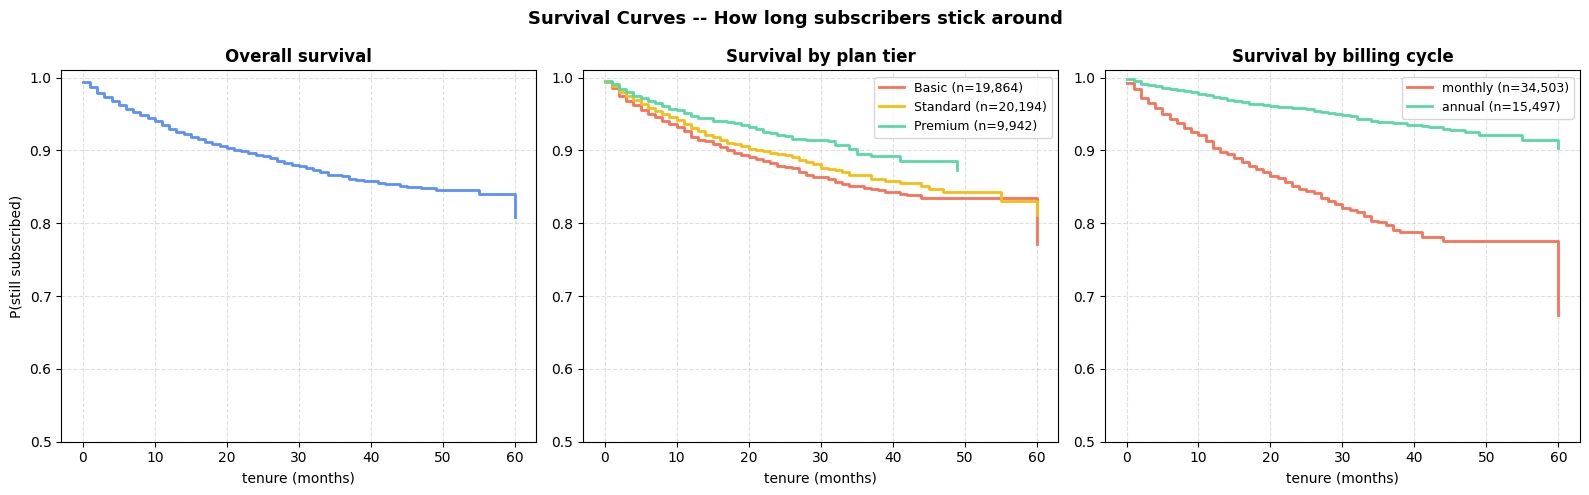

In [4]:
def km(durations, events):
    """Simple Kaplan-Meier estimator. durations = tenure_months, events = churned_next_30d."""
    durations = np.asarray(durations)
    events = np.asarray(events)
    event_times = np.sort(np.unique(durations[events == 1]))
    rows = []
    s = 1.0
    for t in event_times:
        d = ((durations == t) & (events == 1)).sum()
        n = (durations >= t).sum()
        if n == 0:
            break
        s *= (1 - d / n)
        rows.append((t, s, n, d))
    return pd.DataFrame(rows, columns=["t", "S", "at_risk", "events"])


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
overall = km(df["tenure_months"], df["churned_next_30d"])
ax.step(overall["t"], overall["S"], where="post", color="#5B8FF9", linewidth=2)
ax.set_title("Overall survival", fontweight="bold")
ax.set_xlabel("tenure (months)")
ax.set_ylabel("P(still subscribed)")
ax.set_ylim(0.5, 1.01)
ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
plan_colors = {"Basic": "#F6735B", "Standard": "#F6BD16", "Premium": "#5AD8A6"}
for plan, color in plan_colors.items():
    sub = df[df["plan_tier"] == plan]
    curve = km(sub["tenure_months"], sub["churned_next_30d"])
    ax.step(curve["t"], curve["S"], where="post", color=color, linewidth=2,
            label=f"{plan} (n={len(sub):,})")
ax.set_title("Survival by plan tier", fontweight="bold")
ax.set_xlabel("tenure (months)")
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[2]
bill_colors = {"monthly": "#F6735B", "annual": "#5AD8A6"}
for billing, color in bill_colors.items():
    sub = df[df["billing_cycle"] == billing]
    curve = km(sub["tenure_months"], sub["churned_next_30d"])
    ax.step(curve["t"], curve["S"], where="post", color=color, linewidth=2,
            label=f"{billing} (n={len(sub):,})")
ax.set_title("Survival by billing cycle", fontweight="bold")
ax.set_xlabel("tenure (months)")
ax.set_ylim(0.5, 1.01)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Survival Curves -- How long subscribers stick around",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_kaplan_meier.png", dpi=140, bbox_inches="tight")
plt.show()


## D. Churn Rate by Tenure Month

A bar chart of "what fraction of subscribers at this tenure churn in the next
30 days." This is just an easier way to see *when* the spikes happen.

> **Why this view matters for retention timing.** It tells the PM "if you target
> the subscribers currently at month 2 or month 12 with a retention offer right
> now, you're working against a churn rate that's 1.5–2× the average." That's
> when offers pay back fastest. The model in Phase 4 should clearly pick up these
> timing-based risks — if it smooths them away, it'll underweight the moments
> where intervention matters most.


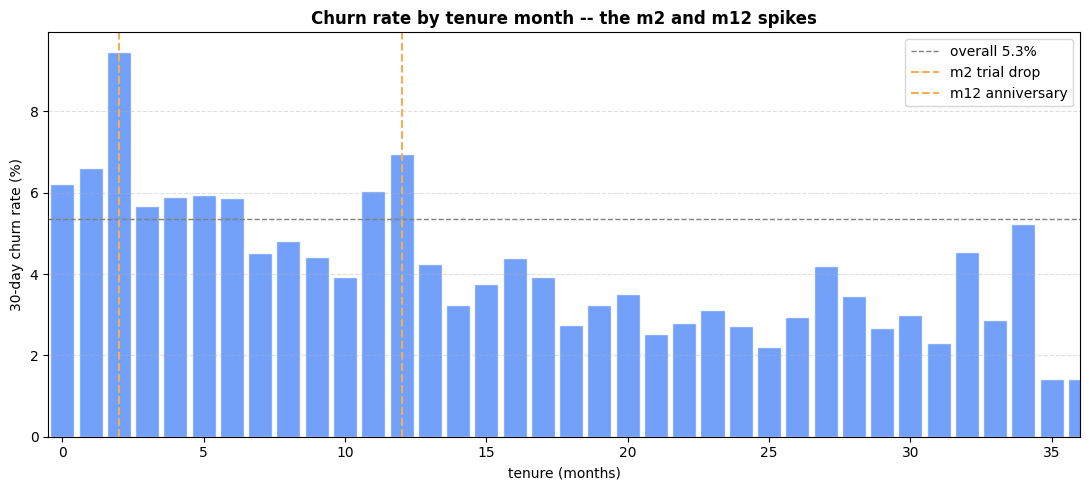

In [5]:
tenure_hazard = (
    df.groupby("tenure_months")["churned_next_30d"]
      .agg(["mean", "count"])
      .reset_index()
      .rename(columns={"mean": "hazard"})
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(tenure_hazard["tenure_months"], tenure_hazard["hazard"] * 100,
       color="#5B8FF9", alpha=0.85, edgecolor="white", width=0.85)
ax.axhline(overall_rate * 100, color="gray", linestyle="--",
           linewidth=1, label=f"overall {overall_rate:.1%}")
ax.axvline(2, color="#F6AD55", linestyle="--", linewidth=1.5, label="m2 trial drop")
ax.axvline(12, color="#F6AD55", linestyle="--", linewidth=1.5, label="m12 anniversary")
ax.set_xlabel("tenure (months)")
ax.set_ylabel("30-day churn rate (%)")
ax.set_title("Churn rate by tenure month -- the m2 and m12 spikes", fontweight="bold")
ax.set_xlim(-0.5, 36)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_tenure_hazard.png", dpi=140, bbox_inches="tight")
plt.show()


## E. Engagement Trend — Are Churners Already Slipping Away?

We built a feature: `(watch_hours_7d × 30/7) / watch_hours_30d`. This compares
recent watching to a 30-day average.
- Less than 1 means recent watching is *below* the 30-day average → they're slipping
- Around 1 means stable
- More than 1 means engagement is *growing*

> **Why this is one of the most useful signals in real retention work.** A user
> who's been steady for years is much safer than a heavy user whose watching
> just dropped 30% from their normal. So the *direction* of their engagement
> matters more than the absolute level. If the two distributions overlap
> completely, our simulator is broken — but if they separate, this single
> feature alone could be one of the model's most powerful inputs.


Trend ratio statistics (watch_hours_7d × 30/7 / watch_hours_30d):
                    count   mean    std    min    25%    50%    75%    max
churned_next_30d                                                          
0                 47328.0  1.053  0.322  0.260  0.824  1.007  1.232  3.000
1                  2672.0  0.928  0.280  0.355  0.731  0.893  1.077  2.363


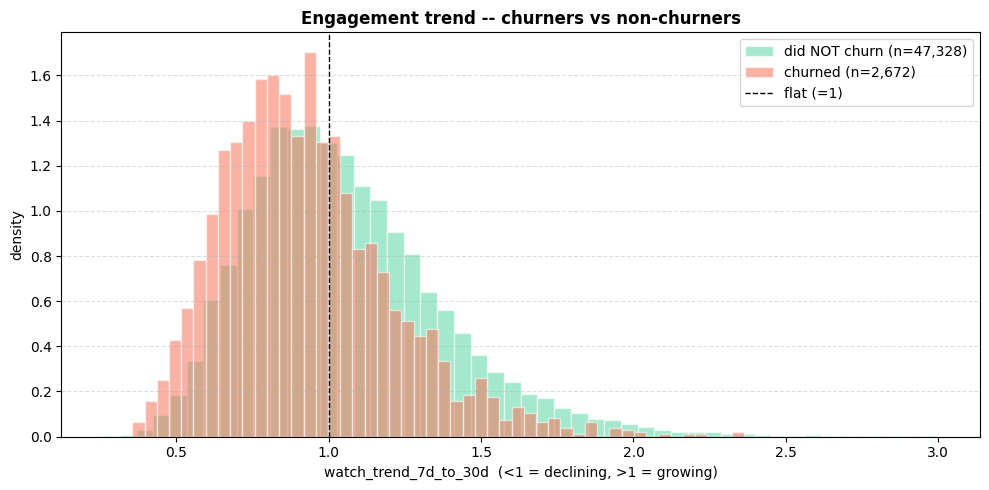

In [6]:
df["watch_trend_7d_to_30d"] = (
    df["watch_hours_last_7d"] * (30 / 7) /
    df["watch_hours_last_30d"].clip(lower=0.1)
).clip(upper=3.0)

print("Trend ratio statistics (watch_hours_7d × 30/7 / watch_hours_30d):")
print(df.groupby("churned_next_30d")["watch_trend_7d_to_30d"]
        .describe(percentiles=[0.25, 0.5, 0.75]).round(3))

fig, ax = plt.subplots(figsize=(10, 5))
for outcome, color, label in [(0, "#5AD8A6", "did NOT churn"), (1, "#F6735B", "churned")]:
    vals = df.loc[df["churned_next_30d"] == outcome, "watch_trend_7d_to_30d"]
    ax.hist(vals, bins=50, alpha=0.55, label=f"{label} (n={len(vals):,})",
            color=color, edgecolor="white", density=True)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="flat (=1)")
ax.set_xlabel("watch_trend_7d_to_30d  (<1 = declining, >1 = growing)")
ax.set_ylabel("density")
ax.set_title("Engagement trend -- churners vs non-churners", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_engagement_trend.png", dpi=140, bbox_inches="tight")
plt.show()


## F. Tenure × User Type — Where Risk Concentrates

A heatmap showing churn rate by **tenure bucket** (rows) and **user type**
(columns). This single chart is the most useful EDA artifact for the PM.

> **Why this is the chart the PM should keep handy.** Looking at one dimension
> at a time can hide important combinations. The heatmap reveals that *casual
> users at month 2* churn 3–8× more than *heavy users at the same point*. That
> kind of difference between groups is exactly what justifies a per-user
> targeting model — you can't capture this with a blanket "send everyone a
> credit" campaign. The decision rule in Phase 6 will focus on the dark red cells.


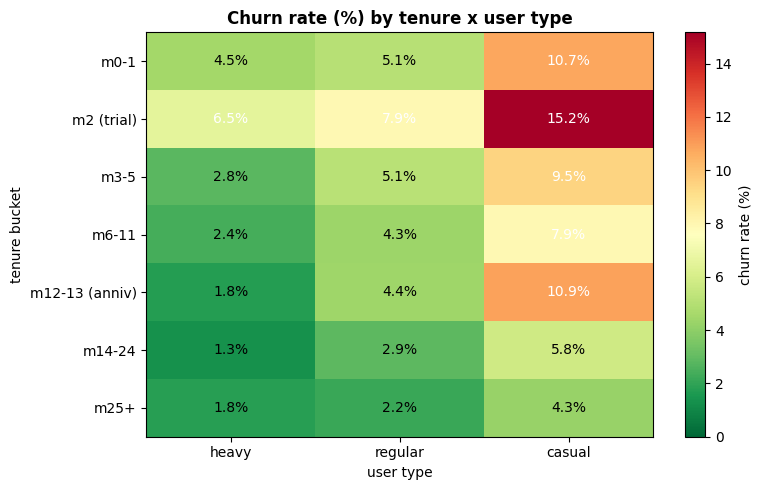


Heatmap values:
engagement_cohort  heavy  regular  casual
tenure_bucket                            
m0-1                4.55     5.07   10.75
m2 (trial)          6.52     7.92   15.17
m3-5                2.79     5.13    9.45
m6-11               2.38     4.33    7.93
m12-13 (anniv)      1.78     4.40   10.88
m14-24              1.31     2.89    5.79
m25+                1.83     2.18    4.26


In [7]:
df["tenure_bucket"] = pd.cut(
    df["tenure_months"],
    bins=[-1, 1, 2, 5, 11, 13, 24, 60],
    labels=["m0-1", "m2 (trial)", "m3-5", "m6-11", "m12-13 (anniv)", "m14-24", "m25+"],
)
heatmap = df.pivot_table(
    index="tenure_bucket", columns="engagement_cohort",
    values="churned_next_30d", aggfunc="mean", observed=True,
)
heatmap = heatmap[["heavy", "regular", "casual"]]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap.values * 100, cmap="RdYlGn_r", aspect="auto",
               vmin=0, vmax=heatmap.values.max() * 100)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_xlabel("user type")
ax.set_ylabel("tenure bucket")
ax.set_title("Churn rate (%) by tenure x user type", fontweight="bold")
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        ax.text(j, i, f"{heatmap.values[i, j] * 100:.1f}%",
                ha="center", va="center", fontsize=10,
                color="white" if heatmap.values[i, j] * 100 > 6 else "black")
plt.colorbar(im, ax=ax, label="churn rate (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_tenure_cohort_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"\nHeatmap values:\n{(heatmap * 100).round(2)}")


## G. Phase 2 Summary — What We Learned

Pulling together the three biggest patterns. These become the things the model
and the decision rule **must** capture.


In [8]:
trend_decline = df.loc[df["churned_next_30d"] == 1, "watch_trend_7d_to_30d"].median()
trend_stable = df.loc[df["churned_next_30d"] == 0, "watch_trend_7d_to_30d"].median()
spread_pp = (
    df.groupby("plan_tier")["churned_next_30d"].mean().max() -
    df.groupby("plan_tier")["churned_next_30d"].mean().min()
) * 100
worst = heatmap.loc["m2 (trial)", "casual"] * 100
best = heatmap.loc["m25+", "heavy"] * 100

print("Key patterns Phase 3+ must capture:")
print(f"  - Plan tier spread:        {spread_pp:.2f}pp churn-rate difference")
print(f"  - Engagement trend median: churners {trend_decline:.3f} vs "
      f"non-churners {trend_stable:.3f}  (<1 = declining)")
print(f"  - Worst group: m2 trial casual users at {worst:.1f}%")
print(f"  - Safest group: m25+ heavy users at {best:.1f}%")
print(f"  - That's a {worst-best:.1f}pp spread between best and worst")


Key patterns Phase 3+ must capture:
  - Plan tier spread:        2.31pp churn-rate difference
  - Engagement trend median: churners 0.893 vs non-churners 1.007  (<1 = declining)
  - Worst group: m2 trial casual users at 15.2%
  - Safest group: m25+ heavy users at 1.8%
  - That's a 13.3pp spread between best and worst


---

## 📝 What to engineer in Phase 3

Based on what we saw above, the priority feature-engineering work is:

1. **Build an "engagement trend" feature.** The chart in Section E shows churners
   and non-churners have clearly different trends — let's give the model that
   ratio directly instead of hoping it figures it out from the raw columns.

2. **Group tenure into named buckets.** Month 2 and month 12 are the spike
   points. Pre-grouping makes the decision rule easier to explain to the PM.

3. **Build "recent vs. older" ratios for tickets and payment failures.** A user
   with 1 ticket from yesterday is much riskier than one with 1 ticket from 80
   days ago. The model can use this directly.

4. **Add a simple "high-risk segment" flag.** Even if the model misses a
   pattern, this gives the Retention team a fallback rule — "always offer
   something to subscribers in their second month with low engagement."

## 🔭 Next: Phase 3 — Feature engineering

With the patterns identified, Phase 3 will build a reusable
`src/features/transforms.py` module that derives these features from the raw
schema. 
